In [1]:
#!pip install pandas

In [2]:
import pandas as pd

In [3]:
dataset = pd.read_csv("placement.csv")

In [4]:
dataset.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [5]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    str    
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    str    
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    str    
 6   hsc_s           215 non-null    str    
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    str    
 9   workex          215 non-null    str    
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    str    
 12  mba_p           215 non-null    float64
 13  status          215 non-null    str    
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), str(8)
memory usage: 25.3 KB


In [6]:
if(dataset["gender"].dtype == "str"):
    print("Qual")
else:
    print("Quan")

Qual


In [7]:
quan = [col for col in dataset if dataset[col].dtype in ['int64', 'float64']]
qual = [col for col in dataset if dataset[col].dtype in ['object', 'category', 'string']]

In [8]:
quan

['sl_no', 'ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'salary']

In [9]:
qual

['gender',
 'ssc_b',
 'hsc_b',
 'hsc_s',
 'degree_t',
 'workex',
 'specialisation',
 'status']

In [10]:
#!pip install numpy

In [12]:
import numpy as np
descriptive = pd.DataFrame(index = ["Mean","Median","Mode","Percentile100","Percentile99","Percentile25","Percentile75","IQR","LowerIQR","GreaterIQR","Min","Max","Skewn","Kurt","vari","sd"], columns = quan)
for columnName in quan:
    descriptive.loc["Mean",columnName] = dataset[columnName].mean()
    descriptive.loc["Median",columnName] = dataset[columnName].median()
    descriptive.loc["Mode",columnName] = dataset[columnName].mode().iloc[0]
    descriptive.loc["Percentile100",columnName] = np.percentile(dataset[columnName],100)
    descriptive.loc["Percentile99",columnName] = np.percentile(dataset[columnName],99)
    descriptive.loc["Percentile25",columnName] = dataset.describe()[columnName]["25%"]
    descriptive.loc["Percentile75",columnName] = dataset.describe()[columnName]["75%"]
    descriptive.loc["IQR",columnName] = dataset.describe()[columnName]["75%"] - dataset.describe()[columnName]["25%"]
    descriptive.loc["LowerIQR",columnName] = dataset.describe()[columnName]["25%"] - (1.5 * (dataset.describe()[columnName]["75%"] - dataset.describe()[columnName]["25%"]) )
    descriptive.loc["GreaterIQR",columnName] = dataset.describe()[columnName]["75%"] + (1.5 * (dataset.describe()[columnName]["75%"] - dataset.describe()[columnName]["25%"]) )
    descriptive.loc["Min",columnName] = dataset[columnName].min()
    descriptive.loc["Max",columnName] = dataset[columnName].max()
    descriptive.loc["Skewn",columnName] = dataset[columnName].skew()
    descriptive.loc["Kurt",columnName] = dataset[columnName].kurtosis()
    descriptive.loc["vari",columnName] = dataset[columnName].var()
    descriptive.loc["sd",columnName] = dataset[columnName].std()

In [13]:
freqTable = pd.DataFrame(columns=["uniq_val","Freq","relative_freq","cummu_freak"])
freqTable["uniq_val"]=dataset["ssc_p"].value_counts().index
freqTable["Freq"]=dataset["ssc_p"].value_counts().values
freqTable["relative_freq"]=(freqTable["Freq"]/103)
freqTable["cummu_freak"]=freqTable["relative_freq"].cumsum()

In [14]:
freqTable

,uniq_val,Freq,relative_freq,cummu_freak
0,62.00,11,0.106796,0.106796
1,63.00,10,0.097087,0.203883
2,67.00,9,0.087379,0.291262
3,73.00,9,0.087379,0.378641
4,52.00,9,0.087379,0.466019
...,...,...,...,...
98,55.68,1,0.009709,2.048544
99,41.00,1,0.009709,2.058252
100,83.33,1,0.009709,2.067961
101,43.00,1,0.009709,2.077670


In [15]:
descriptive

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
Mean,108.0,67.303395,66.333163,66.370186,72.100558,62.278186,288655.405405
Median,108.0,67.0,65.0,66.0,71.0,62.0,265000.0
Mode,1,62.0,63.0,65.0,60.0,56.7,300000.0
Percentile100,215.0,89.4,97.7,91.0,98.0,77.89,NaN
Percentile99,212.86,87.0,91.86,83.86,97.0,76.1142,NaN
Percentile25,54.5,60.6,60.9,61.0,60.0,57.945,240000.0
Percentile75,161.5,75.7,73.0,72.0,83.5,66.255,300000.0
IQR,107.0,15.1,12.1,11.0,23.5,8.31,60000.0
LowerIQR,-106.0,37.95,42.75,44.5,24.75,45.48,150000.0
GreaterIQR,322.0,98.35,91.15,88.5,118.75,78.72,390000.0


In [16]:
if descriptive["ssc_p"]["Min"] < descriptive["ssc_p"]["LowerIQR"]:
    print("Lower")
else:
    print("Normal")

Normal


In [17]:
if descriptive["ssc_p"]["Max"] > descriptive["ssc_p"]["GreaterIQR"]:
    print("Greater")
else:
    print("Normal")

Normal


In [18]:
lowerir = []
greaterir = []

for col in quan:
    # Use .loc[row, col] and pass the variable 'col' without quotes
    if descriptive.loc["Min", col] < descriptive.loc["LowerIQR", col]:
        lowerir.append(col)
        
    if descriptive.loc["Max", col] > descriptive.loc["GreaterIQR", col]:
        greaterir.append(col)

print("Columns with Lower Outliers:", lowerir)
print("Columns with Greater Outliers:", greaterir)

Columns with Lower Outliers: ['hsc_p']
Columns with Greater Outliers: ['hsc_p', 'degree_p', 'salary']


In [19]:
def low_remover(lowerir,descriptive,dataset):
    for i in lowerir:
        lower_limit = descriptive.loc["LowerIQR", i]
        dataset.loc[dataset[i] < lower_limit,i] = lower_limit

In [20]:
low_remover(lowerir,descriptive,dataset)

In [21]:
print("New min hsc_p:", dataset["hsc_p"].min())

New min hsc_p: 42.75


In [22]:
def greater_remover(greaterir,descriptive,dataset):
    for i in greaterir:
        greater_limit = descriptive.loc["GreaterIQR", i]
        dataset.loc[dataset[i] > greater_limit,i] = greater_limit

In [23]:
greater_remover(greaterir,descriptive,dataset)

In [24]:
print("New max hsc_p:", dataset["hsc_p"].max())

New max hsc_p: 91.15


In [25]:
dataset.isnull().sum()

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

In [26]:
dataset.fillna({"salary": 0}, inplace=True)

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,0.0
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,390000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,211,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,390000.0
211,212,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0
212,213,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0
213,214,F,74.00,Others,66.00,Others,Commerce,58.00,Comm&Mgmt,No,70.0,Mkt&HR,60.23,Placed,204000.0


In [27]:
dataset.isnull().sum()

sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64

In [36]:
from matplotlib import pyplot
from scipy.stats import norm
import seaborn as sns
def get_pdf_prob(dataset,start,end):
    ax = sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')
    pyplot.axvline(start,color='Red')
    pyplot.axvline(end,color='Red')
    sample = dataset
    sample_mean = sample.mean()
    sample_std = sample.std()
    print("sample mean:",sample_mean)
    print("sample sd:",sample_std)
    dist = norm(sample_mean,sample_std)
    values = [value for value in range(start,end)]
    probab = [dist.pdf(value) for value in values]
    prob = sum(probab)
    return prob

C:\Users\hemav\AppData\Local\Temp\ipykernel_29620\3455478770.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')


sample mean: 67.30339534883721
sample sd: 10.827205398231452


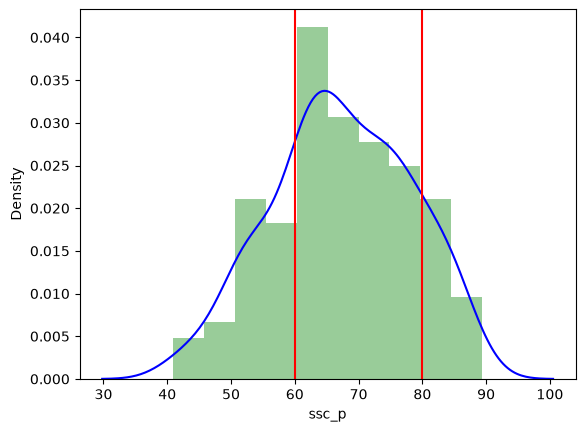

In [37]:
probability = get_pdf_prob(dataset['ssc_p'], 60, 80)

In [43]:
def stdNBgraph(dataset):
    mean = dataset.mean()
    std = dataset.std()
    values = [i for i in dataset]
    z_score = [((j-mean)/std) for j in values]
    sns.distplot(z_score,kde=True)
    sum(z_score)/len(z_score)

C:\Users\hemav\AppData\Local\Temp\ipykernel_29620\3865492358.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(z_score,kde=True)


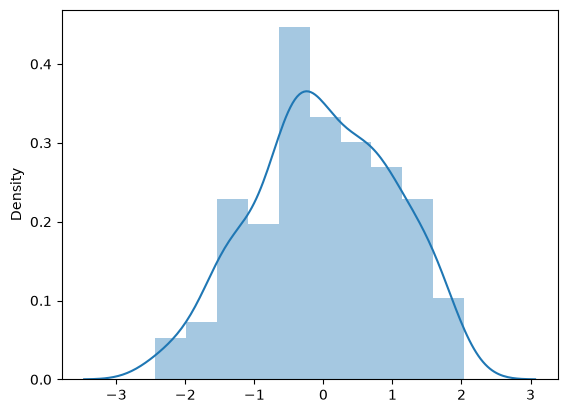

In [44]:
stdNBgraph(dataset['ssc_p'])